<a href="https://colab.research.google.com/github/gianlucamajor/eCruziDB/blob/main/eda/agrs-eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Colab-**eCruzidb** Extended Data Analysis
## AGRs EDA

In [36]:
#@title Install dependencies and loading libs
%time
import os
from io import  StringIO
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
from scipy.stats import zscore


CPU times: user 4 µs, sys: 0 ns, total: 4 µs
Wall time: 8.11 µs


In [37]:
#@title Download data from eCruzidb
# The authority will not require after eCruzidb became open
%time
PE_json_url = "https://projetos.lbi.iq.usp.br/trypanosoma/ecruzidb/data/epitopes-data.json"

br_a4_chrs_url = "https://projetos.lbi.iq.usp.br/trypanosoma/ecruzidb/data/GCA_015033625.1-Br-A4-chromosomes.tsv"
user = "ecruzidb"
password = "setulab"

def PE_data_handler(data):
  df = pd.DataFrame(data)
  # Adjusting columns names
  df = df.rename(columns={"ID":"PE_ID",
                      "Number of Genomic Regions":"Number_of_AGRs",
                      "Number of Peptides":"Number_of_Peptides",
                      "Number of Inserts":"Number_of_Inserts",
                      "Number of Inserts by Group":"Number_of_Inserts_by_Clinical_Group",
                      "Epitope":"PE_Sequence",
                      "Genomic Region Locus":"Locus_of_AGRs"
                      }).copy()
  df['GAGR-ID'] = df['PE_ID'].apply(lambda x: x.split('-')[0]) # The GAGR could has zero, one or more PE.
  return df



# Predicted Epitope Data
PE_response = requests.get(PE_json_url, auth=(user, password))
if PE_response.status_code == 200:
    data = PE_response.json()
    PEs_df = PE_data_handler(data)

else:
    print(f"Failed to fetch data: {PE_response.status_code}")

# Br-A4 chromosomes data
br_a4_chrs_response = requests.get(br_a4_chrs_url, auth=(user, password))
if br_a4_chrs_response.status_code == 200:
    tsv_data = StringIO(br_a4_chrs_response.text)
    # original source: https://www.ncbi.nlm.nih.gov/datasets/genome/GCA_015033625.1/
    br_a4_chrs_complete_df = pd.read_csv(tsv_data, sep="\t")

else:
    print(f"Failed to fetch data: {br_a4_chrs_response.status_code}")



CPU times: user 2 µs, sys: 0 ns, total: 2 µs
Wall time: 4.77 µs


In [38]:
#@title Preprocessing chromosomes data: Building the pseudochromosome from unplaced scaffolds


def create_accession_and_contig_number(row):
  gbSeqAccession = row['GenBank seq accession']
  seqName = row['Sequence name']

  gbSeqAccessionNumber = int(gbSeqAccession.split('WNWZ')[1].split('.')[0])
  contigNumber = int(seqName.split('TcBrA4_Contig')[1])
  row['gbSeqAccessionNumber'] = gbSeqAccessionNumber
  row['contigNumber'] = contigNumber

  return row

# keep only useful columns
br_a4_chrs_df = br_a4_chrs_complete_df[['Chromosome name', 'GenBank seq accession', 'Seq length', 'Sequence name']].copy()

# select only unplacesd scaffolds
br_a4_scaffolds = br_a4_chrs_df[br_a4_chrs_df['GenBank seq accession'].str.startswith("WNWZ")]
br_a4_scaffolds = br_a4_scaffolds.apply(lambda row: create_accession_and_contig_number(row), axis=1)

## Sorting the dataframe is fundamental for next steps
br_a4_scaffolds

br_a4_scaffolds.sort_values(by="gbSeqAccessionNumber", ascending=True, inplace=True)
br_a4_scaffolds.reset_index(drop=True, inplace=True)


## create a pseudochromosome to aggregate all unplaced scaffolds

start = 0
for i, row in br_a4_scaffolds.iterrows():
  # print(row['Seq length'])
  br_a4_scaffolds.loc[i, 'pse_chr_start'] = f"{start:d}"
  br_a4_scaffolds.loc[i, 'pse_chr_end'] = f"{start + row['Seq length']:d}"
  start = start + row['Seq length']

##

scaffold_id_and_start = {}
for i, row in br_a4_scaffolds.iterrows():
  scaffold_id_and_start[row['GenBank seq accession']] = row['pse_chr_start']

# scaffold_id_and_start

# br_a4_scaffolds


In [39]:
#@title Preprocessing chromosomes data:
br_a4_chrs_df = br_a4_chrs_complete_df[['Chromosome name', 'GenBank seq accession', 'Seq length']].copy()
br_a4_chrs_df.columns = ['chr', 'GBSeqAccession', 'SeqLength']
br_a4_chrs_df.set_index('GBSeqAccession', inplace=True)
br_a4_chrs_dict =  br_a4_chrs_df.to_dict(orient='index')

br_a4_chrs_dict

sectors = {}
for k in br_a4_chrs_dict.keys():
  chr = br_a4_chrs_dict.get(k).get('chr')
  length = br_a4_chrs_dict.get(k).get('SeqLength')
  if chr.isdigit(): # Only numeric (placed) chromosomes
    sectors[chr]=length

# add pseudochromosome 99
sectors['99'] = 8859753

chr_size = sectors


In [40]:
#@title Prepare dataframe
PEs_distinct_AGRs_df = PEs_df.drop_duplicates(subset=['GAGR-ID']).copy() # Keep just distinct AGRs Locus

def create_agrs_with_chr_info(agr_locus_list, chrs):
  agr_list_with_chr_info = []
  for agr in agr_locus_list:
    agr_splited = agr.split(':')
    chr_name = agr_splited[0]
    chr_start_end = agr_splited[1]
    # print(chr_start_end)
    chr = chrs.get(chr_name).get('chr')
    if chr.isnumeric():
      chr_gr = f"{chr}:{chr_start_end}"
    else:
      chr_gr = agr
    agr_list_with_chr_info.append(chr_gr)

  return agr_list_with_chr_info

# Get pseudochromosomes coodinates
def get_pse_chr_coordinates(row, scaffold_id_and_start):
  chr_ghost_start = int(scaffold_id_and_start[row['chromosome']])

  row['pse_chr_start'] = chr_ghost_start + int(row['start'])
  row['pse_chr_end'] = chr_ghost_start + int(row['end'])

  return row



# Create column with AGRs with numeric chr info
PEs_distinct_AGRs_df['AGRs_with_chr_info'] = PEs_distinct_AGRs_df.apply(lambda row: create_agrs_with_chr_info(row['Locus_of_AGRs'],br_a4_chrs_dict), axis=1)


## Show number of antigenic genomic regions
unique_AGRs_set = set()
AGRs_list = []
for region_list in PEs_distinct_AGRs_df['AGRs_with_chr_info']:
  for region in region_list:
    r_splited = region.split(':')
    chr = r_splited[0]
    start_end = r_splited[1]

    start = start_end.split('-')[0]
    end = start_end.split('-')[1]
    AGRs_list.append([chr,start, end])
    unique_AGRs_set.add(region)

t = unique_AGRs_set
# display(sorted(genomic_regions))

all_AGRs = pd.DataFrame(sorted(AGRs_list), columns=['chromosome', 'start', 'end'])


scaffold_AGRs = all_AGRs[all_AGRs['chromosome'].str.startswith("WNWZ")]

# from scaffold_AGRs to pseudochromosome

scaffold_id_and_start = {}
for i, row in br_a4_scaffolds.iterrows():
  scaffold_id_and_start[row['GenBank seq accession']] = row['pse_chr_start']


FROM_scaffold_TO_pse_chr_AGRs = scaffold_AGRs.apply(lambda row: get_pse_chr_coordinates(row, scaffold_id_and_start), axis=1)

# print(f"From scaffold To pseudochromosome")
# display(FROM_scaffold_TO_pse_chr_AGRs)



# create pseudochromosome 99 as a chr numeric

chr_99 = FROM_scaffold_TO_pse_chr_AGRs[['pse_chr_start', 'pse_chr_end']].copy()
chr_99['chromosome'] = 99
chr_99.columns = ['start', 'end', 'chromosome']
pse_chr_99_df = chr_99[["chromosome", "start", "end"]]
pse_chr_99_df

# print(f"AGRs from Pseudochromosome 99")
# display(pse_chr_99_df)

# create the numeric chromosomes

placed_numeric_chrs_df = all_AGRs[all_AGRs['chromosome'].str.isdigit()].copy()

# print(f"AGRs from Numeric Chromosomes")
# display(placed_numeric_chrs_df)


numeric_and_pse_chrs_df = pd.concat([placed_numeric_chrs_df,pse_chr_99_df])
print(f"AGRs from Numeric and Pseudochromosomes")
display(numeric_and_pse_chrs_df)


AGRs from Numeric and Pseudochromosomes


,chromosome,start,end
0,1,1003884,1003978
1,1,1005155,1005243
2,1,1018349,1018488
3,1,1023564,1023709
4,1,1032501,1032685
...,...,...,...
21133,99,8855220,8855329
21134,99,8857115,8857209
21135,99,8826798,8827047
21136,99,8834287,8834333


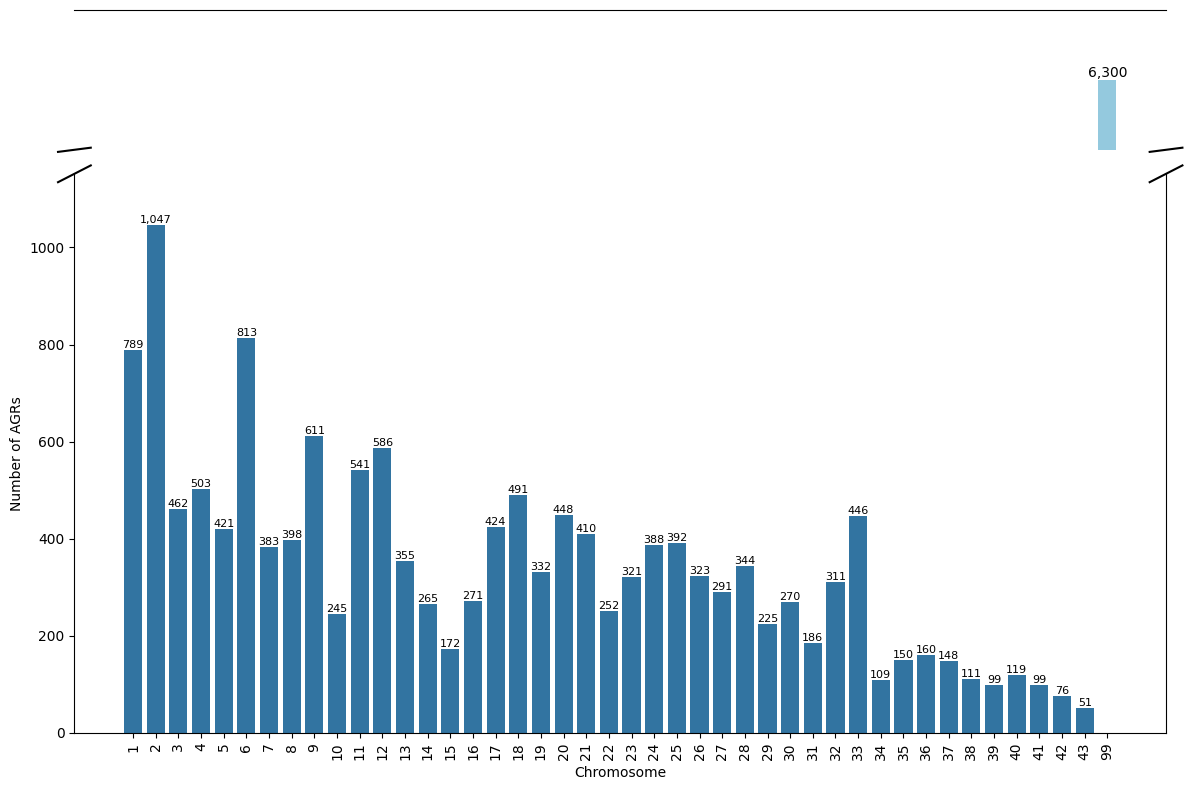

In [41]:
#@title (A): AGRs Genome-wide distribution
numeric_and_pse_chrs_df = numeric_and_pse_chrs_df.astype(int)
chromosome_counts = numeric_and_pse_chrs_df['chromosome'].value_counts().sort_index()


# Separate data for normal chromosomes and chr99 (counts)
normal_chromosomes_counts = chromosome_counts[chromosome_counts.index != 99]
chr99_count_series = chromosome_counts[chromosome_counts.index == 99]


# Create a master list of chromosome names for consistent x-axis ordering
all_chrom_labels = [str(i) for i in range(1, 44)] + ['99']

# Prepare data for the lower subplot (chromosomes 1-43)
# Create a DataFrame for seaborn, ensuring '99' has NaN or 0 count for this plot
plot_df_lower_data = chromosome_counts.reindex([int(x) for x in all_chrom_labels]).fillna(0)
plot_df_lower_data.loc[99] = 0 # Set count for chr99 to 0 on the lower plot
plot_df_lower = pd.DataFrame({
    'chromosome': plot_df_lower_data.index.astype(str),
    'count': plot_df_lower_data.values
})

# Prepare data for the upper subplot (chromosome 99)
# Create a DataFrame for seaborn, ensuring other chroms have NaN or 0 count for this plot
plot_df_upper_data = chromosome_counts.reindex([int(x) for x in all_chrom_labels]).fillna(0)
plot_df_upper_data.loc[[int(x) for x in all_chrom_labels[:-1]]] = 0 # Set counts for 1-43 to 0
plot_df_upper = pd.DataFrame({
    'chromosome': plot_df_upper_data.index.astype(str),
    'count': plot_df_upper_data.values
})

# Create a figure and two subplots
fig, (ax_upper, ax_lower) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={'height_ratios': [1, 4]})

# --- Upper subplot (for chr99) ---
sns.barplot(x='chromosome', y='count', data=plot_df_upper, ax=ax_upper, order=all_chrom_labels, palette='dark:skyblue', hue='chromosome', legend=False)
ax_upper.set_ylim(chr99_count_series.min() * 0.9, chr99_count_series.max() * 1.1)
ax_upper.spines[['bottom', 'left', 'right']].set_visible(False)
ax_upper.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
ax_upper.set_ylabel('')
ax_upper.tick_params(axis='y', length=0, labelleft=False) # Remove y-ticks and labels

# Add the count value on top of the chr99 bar
if not chr99_count_series.empty:
    x_pos_99_bar = all_chrom_labels.index('99')
    count_99 = chr99_count_series.iloc[0]
    ax_upper.text(x_pos_99_bar, count_99, f'{int(count_99):,}', ha='center', va='bottom', fontsize=10, color='black')

# --- Lower subplot (for normal chromosomes) ---
sns.barplot(x='chromosome', y='count', data=plot_df_lower, ax=ax_lower, order=all_chrom_labels)
ax_lower.set_ylim(0, normal_chromosomes_counts.max() * 1.1)
ax_lower.spines[['top']].set_visible(False)
ax_lower.set_xlabel('Chromosome')
ax_lower.set_ylabel('Number of AGRs')
ax_lower.tick_params(axis='x', rotation=90)

# Add values on top of the bars in the lower plot
for container in ax_lower.containers:
    for p in container.patches:
        height = p.get_height()
        if height > 0: # Only add label if bar is visible
            ax_lower.text(p.get_x() + p.get_width() / 2., height, f'{int(height):,}', ha='center', va='bottom', fontsize=8, color='black')

# Add the 'break' indicator for the y-axis
d_upper = .015
d_lower = .015

kwargs = dict(transform=ax_upper.transAxes, color='k', clip_on=False)
ax_upper.plot((-d_upper, +d_upper), (-d_upper, +d_upper), **kwargs)
ax_upper.plot((1 - d_upper, 1 + d_upper), (-d_upper, +d_upper), **kwargs)

kwargs.update(transform=ax_lower.transAxes)
ax_lower.plot((-d_lower, +d_lower), (1 - d_lower, 1 + d_lower), **kwargs)
ax_lower.plot((1 - d_lower, 1 + d_lower), (1 - d_lower, 1 + d_lower), **kwargs)

ax_upper.set_title('')
plt.subplots_adjust(hspace=0.05)
plt.tight_layout()
plt.show()

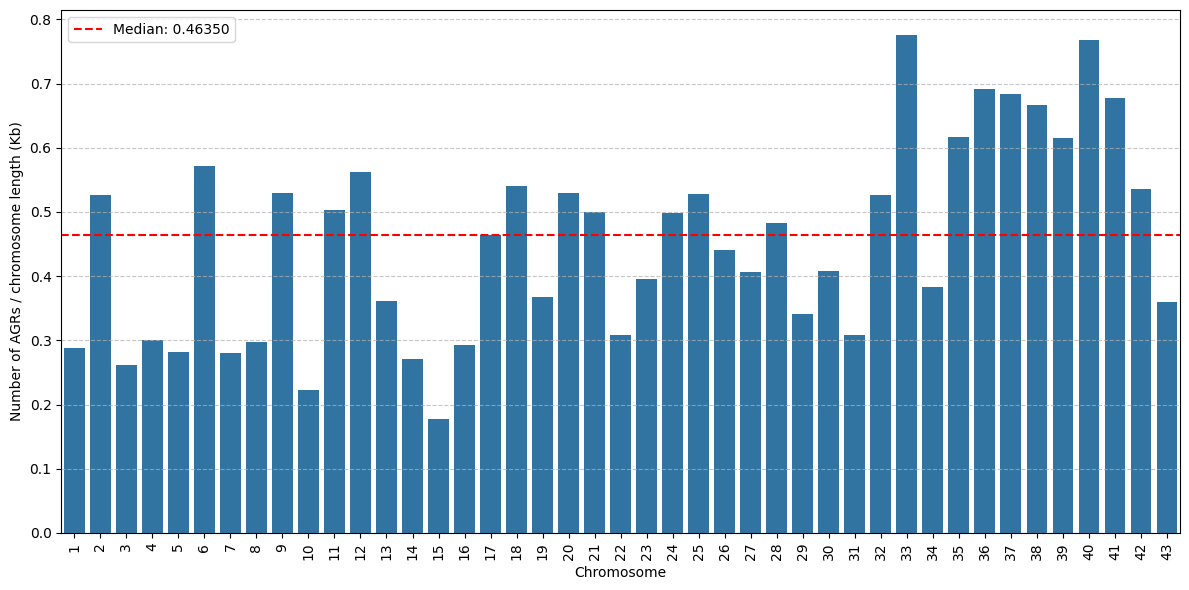

In [42]:
#@title (B): AGRs length-normalized
# Chromosomes
numeric_and_pse_chrs_df = numeric_and_pse_chrs_df.astype(int)

# Count the frequency of each numeric chromosome (this is the number of genomic regions)
chromosome_counts = numeric_and_pse_chrs_df['chromosome'].value_counts().sort_index()

# Convert chromosomes_size dictionary to a pandas Series for easy alignment and convert to Kb
chromosomes_length_series_kb = (pd.Series(chr_size) / 1000).astype(float) # Divide by 1000 for Kb
chromosomes_length_series_kb.index = chromosomes_length_series_kb.index.astype(int)

# Filter out chromosome 99 from chromosome_counts and chromosomes_length_series_kb
chromosome_counts_no_99 = chromosome_counts[chromosome_counts.index != 99]
chromosomes_length_series_kb_no_99 = chromosomes_length_series_kb[chromosomes_length_series_kb.index != 99]

# Align chromosome_counts with chromosomes_length_series and perform division
# We'll use .reindex to ensure alignment, filling missing values if any (though none expected here)
normalized_counts_no_99 = chromosome_counts_no_99 / chromosomes_length_series_kb_no_99.reindex(chromosome_counts_no_99.index)

# Create a bar plot for the normalized values (excluding chr 99)
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=normalized_counts_no_99.index, y=normalized_counts_no_99.values)
plt.xticks(rotation=90)
plt.xlabel('Chromosome')
plt.ylabel('Number of AGRs / chromosome length (Kb)')
plt.title('')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add median line (excluding chr 99 from calculation)
median_density = normalized_counts_no_99.median()
plt.axhline(median_density, color='red', linestyle='--', label=f'Median: {median_density:.5f}')

plt.legend()
plt.tight_layout()
plt.show()

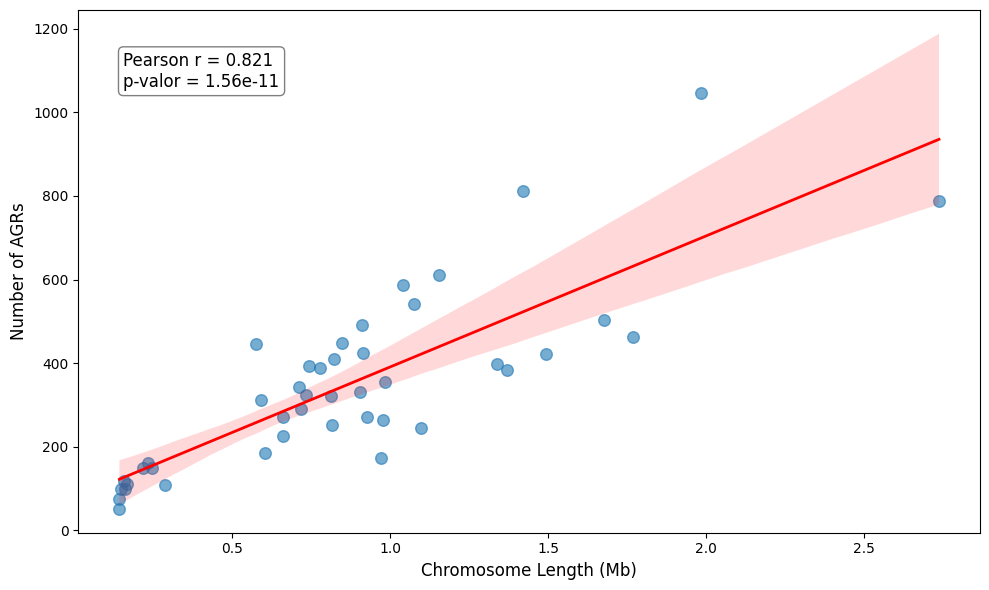

In [43]:
#@title (C) Correlation between chromosome length and AGRs abundance
from scipy.stats import pearsonr

def get_length_of_chr(row, chromosomes_size):
  chr_length = chromosomes_size[row['chr']]
  row['chr_length_mb'] = chr_length / 1000000
  return row


agrs_by_chr_df = plot_df_lower[plot_df_lower['chromosome'].astype(int) <= 43].copy() # remove fake chr 99
agrs_by_chr_df.rename(columns={'chromosome': 'chr', 'count': 'AGRs'}, inplace=True)
agrs_by_chr_df = agrs_by_chr_df.apply(lambda row: get_length_of_chr(row, chr_size), axis=1) # get chr length in milion of bases (Mb)

corr, p_valor = pearsonr(agrs_by_chr_df['AGRs'], agrs_by_chr_df['chr_length_mb'])

# print(f"Pearson: {corr:.4f}")
# print(f"p-value: {p_valor:.2e}")


# Configurações visuais
plt.figure(figsize=(10, 6))
# sns.set_theme(style="whitegrid") # NOTE: Can modify theme/style of other figures.

# Cria o gráfico com linha de regressão
ax = sns.regplot(data=agrs_by_chr_df, x='chr_length_mb', y='AGRs',
                 scatter_kws={'alpha':0.6, 's':70},
                 line_kws={'color':'red', 'lw':2})

# Texto com os resultados (Formatando p-valor em notação científica se for muito pequeno)
texto_stats = f'Pearson r = {corr:.3f}\np-valor = {p_valor:.2e}'

# Adiciona o texto dentro do gráfico
# Os valores 0.05 e 0.95 referem-se à posição (x, y) relativa aos eixos (0 a 1)
plt.text(0.05, 0.92, texto_stats, transform=ax.transAxes, fontsize=12,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

plt.title(f'')
plt.xlabel('Chromosome Length (Mb)', fontsize=12)
plt.ylabel('Number of AGRs', fontsize=12)

plt.tight_layout()
plt.show()
